In [ ]:
# WEEK 2

# “Know Your Data”

# Netflix Viewing Pattern Analysis

# Name:** Sahana Viyani A
# Roll No:** 25BAD092
# Role:** Data Visualizer


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [6]:
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/netflix_data')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
df = pd.read_csv('/content/netflix_data/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [9]:
df.shape

df.columns

df.info()

df.describe(include='all')



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


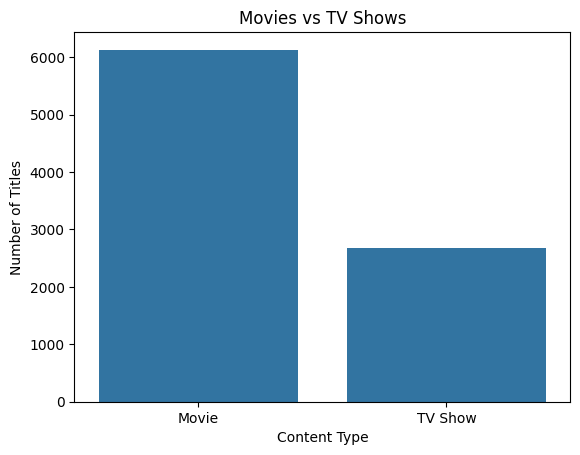

In [12]:
sns.countplot(data=df, x='type')

plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

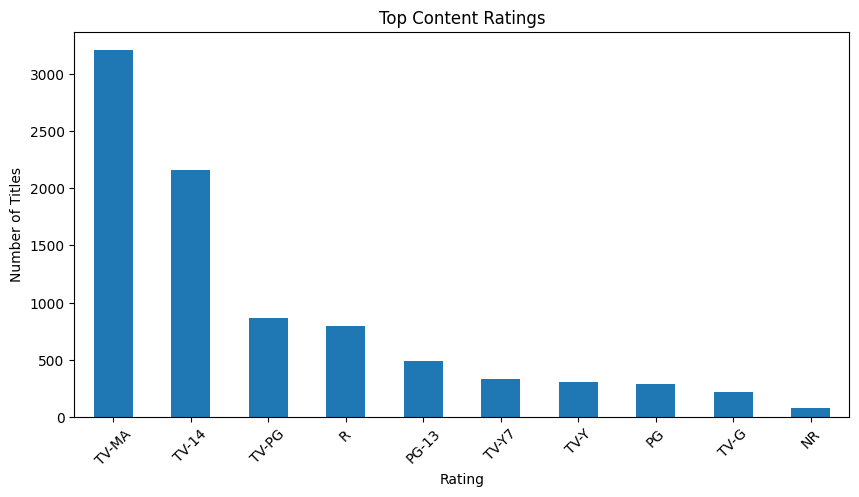

In [13]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Top Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

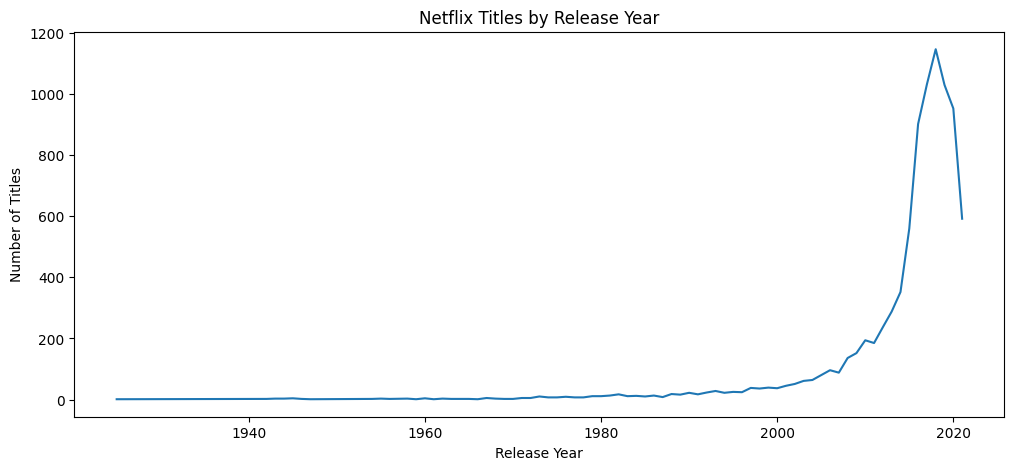

In [14]:
plt.figure(figsize=(12,5))

df['release_year'].value_counts().sort_index().plot()

plt.title('Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

In [ ]:
# Week 2 – First Impression Report

#The Netflix dataset was loaded and its structure, columns, data types,
#Basic visualizations were created to understand the distribution of Movies
#and TV Shows, content ratings and release years.

#These initial observations provide a foundation for the data cleaning and
#detailed EDA activities in the following weeks.

In [ ]:
# WEEK 3

# The Cleaning Sprint — Handling Missing Values (Imputation strategies) and Outlier Detection (Boxplots/Z-score).

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

sns.set_theme(style="whitegrid")

In [16]:
# Check Missing Values
missing = df.isnull().sum()

print(missing)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


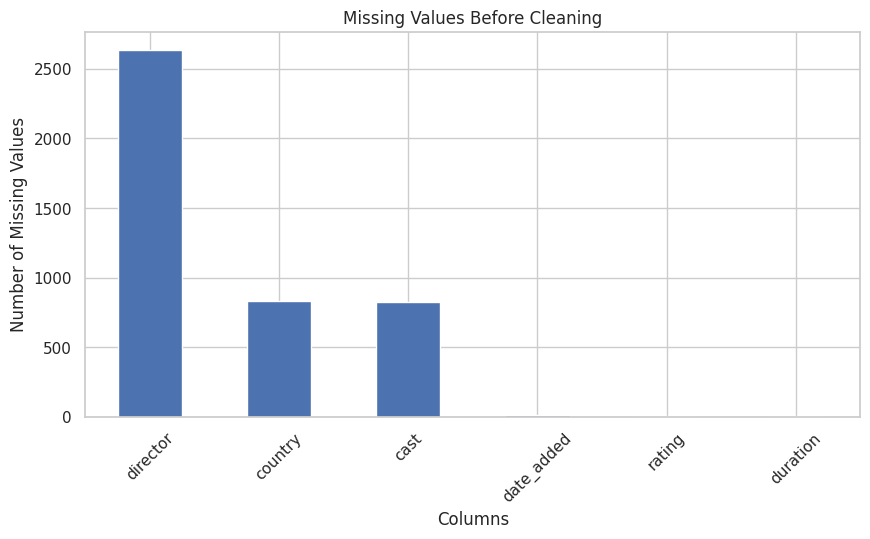

In [17]:
# Visualize missing values
plt.figure(figsize=(10,5))

missing[missing > 0].sort_values(ascending=False).plot(kind='bar')

plt.title('Missing Values Before Cleaning')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)

plt.show()

In [18]:
#Handle Missing Values
cleaned_df = df.copy()

cleaned_df['director'] = cleaned_df['director'].fillna('Unknown')
cleaned_df['cast'] = cleaned_df['cast'].fillna('Unknown')
cleaned_df['country'] = cleaned_df['country'].fillna('Unknown')

cleaned_df['rating'] = cleaned_df['rating'].fillna(cleaned_df['rating'].mode()[0])
cleaned_df['duration'] = cleaned_df['duration'].fillna('Unknown')
cleaned_df['date_added'] = cleaned_df['date_added'].fillna('Unknown')

In [19]:
before = df.isnull().sum()
after = cleaned_df.isnull().sum()

comparison = pd.DataFrame({
    'Before Cleaning': before,
    'After Cleaning': after
})

comparison = comparison[comparison['Before Cleaning'] > 0]

print(comparison)

            Before Cleaning  After Cleaning
director               2634               0
cast                    825               0
country                 831               0
date_added               10               0
rating                    4               0
duration                  3               0


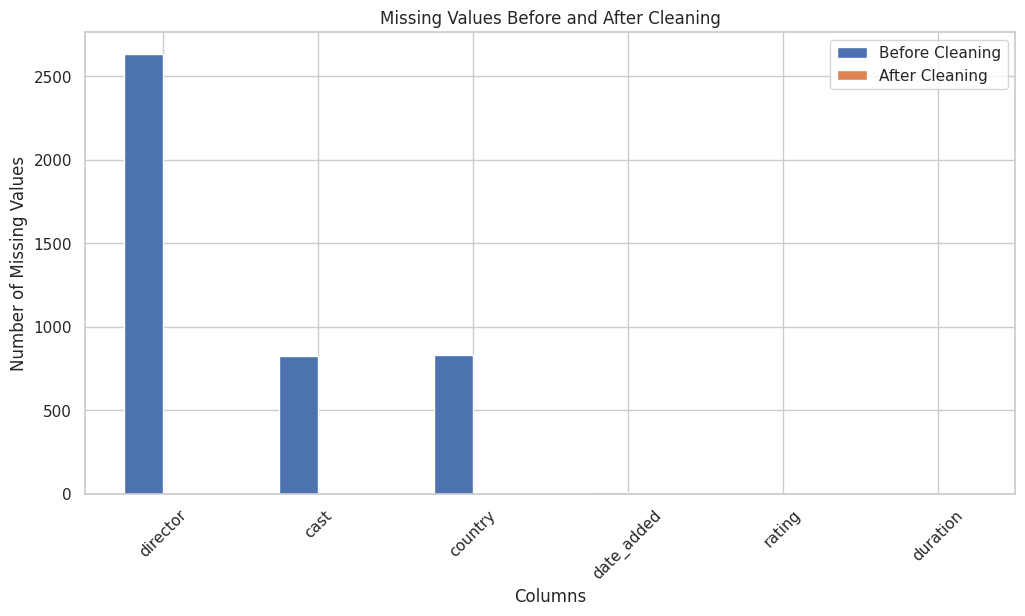

In [20]:
comparison.plot(kind='bar', figsize=(12,6))

plt.title('Missing Values Before and After Cleaning')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)

plt.show()

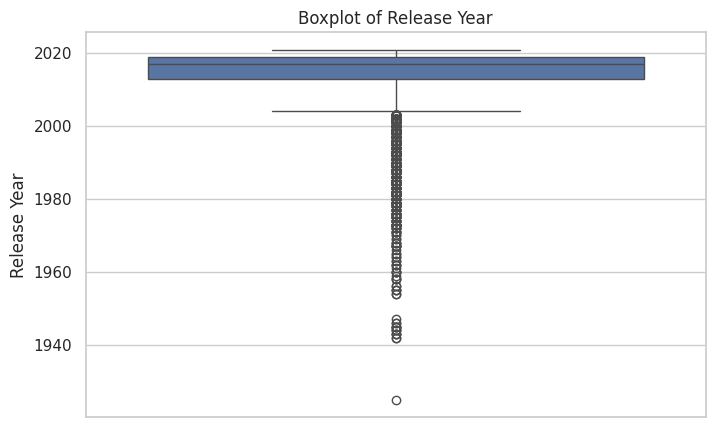

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(y=cleaned_df['release_year'])

plt.title('Boxplot of Release Year')
plt.ylabel('Release Year')

plt.show()

In [22]:
from scipy.stats import zscore

z_scores = np.abs(zscore(cleaned_df['release_year']))

outliers = cleaned_df[z_scores > 3]

print("Number of outliers:", len(outliers))

Number of outliers: 217


In [23]:
# Final Cleaning Check
print("Missing values after cleaning:")
print(cleaned_df.isnull().sum())

print("\nDuplicate rows:", cleaned_df.duplicated().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Duplicate rows: 0


In [ ]:
# Week 3 – Cleaning and Visualization Summary

#Missing values were identified and visualized using Pandas and Matplotlib.
#Categorical missing values were handled using "Unknown", while the mode was
#used for the missing rating values.

#Before-and-after visualizations were created to compare the missing-value
#status.

#A boxplot and Z-score method were used to inspect potential outliers in the
#release_year variable.

#The cleaned dataset is now prepared for further EDA.

In [24]:
# WEEK 4

# EDA Deep Dive: Univariate and Bivariate Analysis + Visualizing Distributions.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [26]:
df = cleaned_df.copy()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


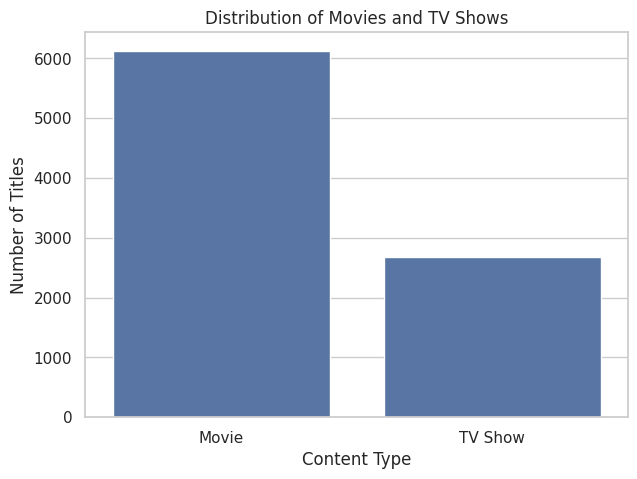

In [27]:
#Univariate Analysis
# Cell 3 — Movies vs TV Shows

plt.figure(figsize=(7,5))

sns.countplot(data=df, x='type')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

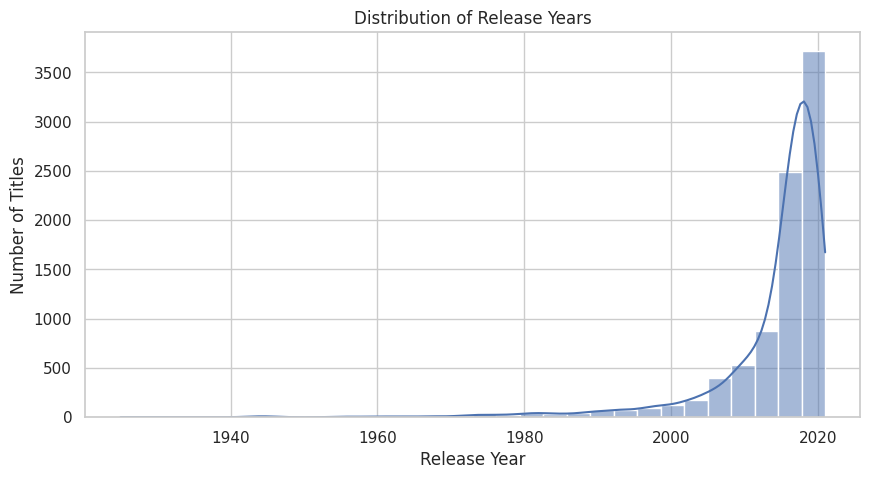

In [28]:
# Release Year Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['release_year'], bins=30, kde=True)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

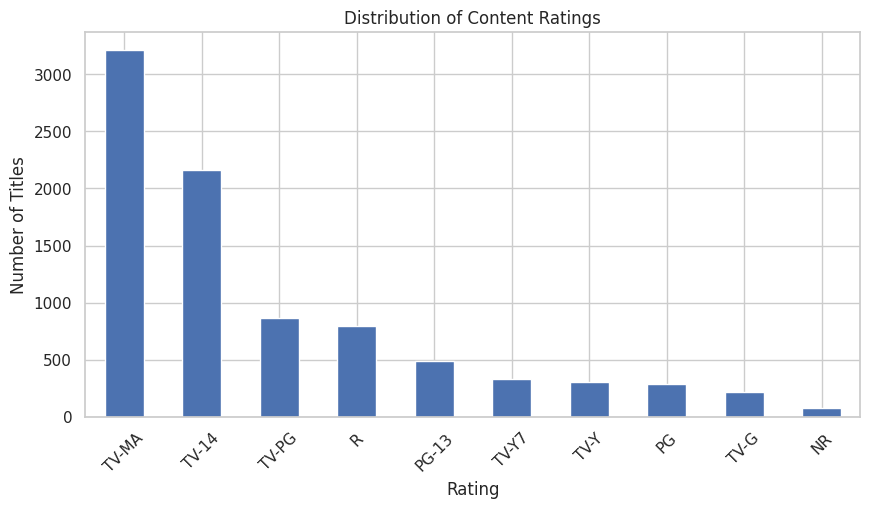

In [29]:
# Content Ratings

plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

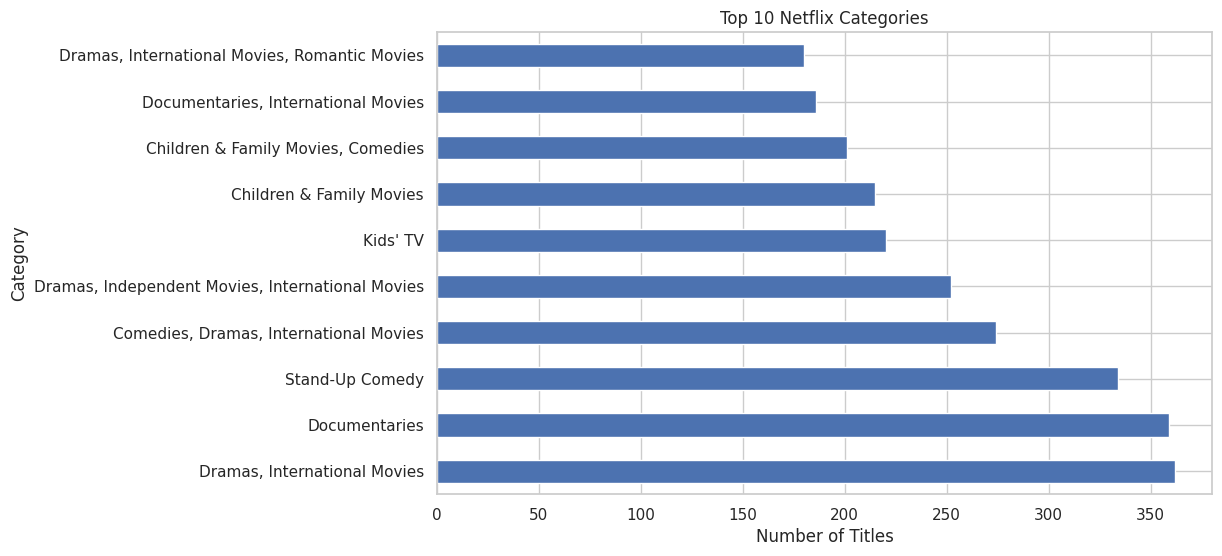

In [30]:
# Top 10 Categories

plt.figure(figsize=(10,6))

df['listed_in'].value_counts().head(10).plot(kind='barh')

plt.title('Top 10 Netflix Categories')
plt.xlabel('Number of Titles')
plt.ylabel('Category')
plt.show()

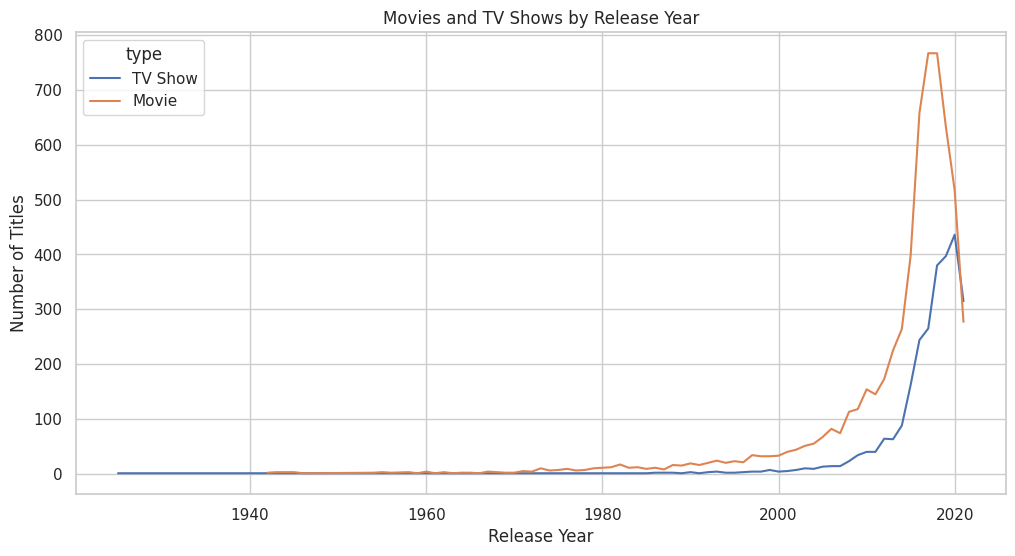

In [31]:
# . Bivariate Analysis
# Cell 7 — Content Type vs Release Year

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df.groupby(['release_year', 'type']).size().reset_index(name='count'),
    x='release_year',
    y='count',
    hue='type'
)

plt.title('Movies and TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

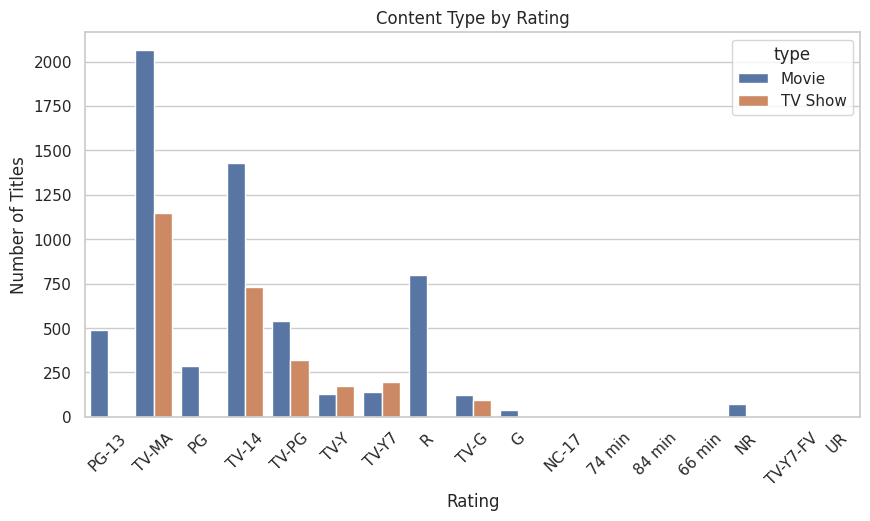

In [32]:
# Content Type vs Rating

plt.figure(figsize=(10,5))

sns.countplot(data=df, x='rating', hue='type')

plt.title('Content Type by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [33]:
# Simple Summary

print("Most common content type:")
print(df['type'].mode()[0])

print("\nMost common rating:")
print(df['rating'].mode()[0])

print("\nMost common category:")
print(df['listed_in'].mode()[0])

Most common content type:
Movie

Most common rating:
TV-MA

Most common category:
Dramas, International Movies


In [ ]:
# Week 4 – EDA Findings

#Univariate analysis was performed to study individual variables such as
#content type, release year, ratings and categories.

#Bivariate analysis was performed to examine relationships between content
#type and release year, and between content type and ratings.

#The visualizations helped identify major patterns and distributions in the
#Netflix catalogue and provide a deeper understanding of the dataset.